# Module 5 — Model Development
### Real-time payment fraud detection for an e-commerce platform

**Input:** `data/processed/features_train.parquet`, `features_test.parquet`,
`models/feature_list.json`, `models/scaler.joblib` (Module 4 outputs)
**Outputs:**
- `models/best_model.joblib`, `models/decision_threshold.json` — for deployment (Module 6)
- `Module_08/` — model-comparison table, cost sensitivity, cost curve & PR-curve figures

This module trains and compares three classifiers and then does the part that
actually matters for the business: **it chooses an operating threshold by minimising
a cost model**, not by maximising accuracy.

Two principles drive everything here:

1. **The right metrics for imbalance.** At this prevalence, accuracy and ROC-AUC are
   misleading (a do-nothing model scores ~99.9% accuracy and ~0.5–0.9 ROC-AUC). We
   judge models on **AUC-PR (average precision), precision, recall, and F1**, and we
   choose the operating point on a **net-cost** curve.
2. **Cost, not a default 0.5 threshold.** A missed fraud costs roughly its dollar
   `amount` (`C_fn`); a false alarm costs a fixed review/friction amount (`C_fp`).
   The operating threshold minimises `net_cost`, and we report the whole trade-off
   curve plus a sensitivity analysis on `C_fp` — because that constant is a business
   assumption, not a fact.

> Assumes Module 4 has been run (the feature parquets carry an unscaled `amount_raw`
> audit column, which is what the cost model needs).

## Setup & load model-ready data

In [1]:
import sys, json
from pathlib import Path

def _find_root(start: Path) -> Path:
    p = start.resolve()
    for cand in [p, *p.parents]:
        if (cand / "scripts" / "config.py").exists():
            return cand
    return p
ROOT_GUESS = _find_root(Path.cwd())
if str(ROOT_GUESS) not in sys.path:
    sys.path.insert(0, str(ROOT_GUESS))

from scripts.config import ROOT, DATA_PROCESSED, FIGURES

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight",
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})

REPORTS = ROOT / "Module_08"; MODELS = ROOT / "models"
REPORTS.mkdir(parents=True, exist_ok=True); MODELS.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name):
    p = FIGURES / f"{name}.png"; fig.savefig(p); print(f"figure -> {p.relative_to(ROOT)}")
def save_table(df, name, index=True):
    p = REPORTS / f"{name}.csv"; df.to_csv(p, index=index); print(f"table  -> {p.relative_to(ROOT)}")

meta = json.loads((MODELS / "feature_list.json").read_text())
FEATURES, LABEL = meta["features"], meta["label"]
class_weight = {int(k): v for k, v in meta["class_weight"].items()}

train = pd.read_parquet(DATA_PROCESSED / "features_train.parquet")
test  = pd.read_parquet(DATA_PROCESSED / "features_test.parquet")
X_train, y_train = train[FEATURES], train[LABEL].astype(int)
X_test,  y_test  = test[FEATURES],  test[LABEL].astype(int)
amount_test = test["amount_raw"].to_numpy()   # unscaled $ for the cost model

print(f"train {X_train.shape} fraud={int(y_train.sum())} ({y_train.mean()*100:.3f}%)")
print(f"test  {X_test.shape} fraud={int(y_test.sum())} ({y_test.mean()*100:.3f}%)")
print(f"class_weight from Module 4: {class_weight}")
print(f"total fraud $ at risk in test: {amount_test[y_test.values==1].sum():,.0f}")

train (2217905, 46) fraud=3955 (0.178%)
test  (552504, 46) fraud=4258 (0.771%)
class_weight from Module 4: {0: 0.5009, 1: 280.3925}
total fraud $ at risk in test: 6,702,594,765


## 1. A necessary caution: PaySim's mechanical balance features

**Reasoning.** PaySim has a well-known property: fraudulent `TRANSFER`/`CASH_OUT`
rows nearly satisfy an accounting identity — the origin is drained
(`oldbalanceOrg ≈ amount`, `newbalanceOrig = 0`) and destination balances are often
masked to zero. Features built from balances therefore encode the fraud *mechanism*
almost deterministically. A model given them can look **too perfect** (AUC-PR ≈ 1.0),
which is not skill — it is the simulator's structure leaking through.

**What to look for.** The balance/amount group separating the classes far more than
the behavioural/contextual group. We quantify this explicitly and then train **two
variants**: a *full* model (all features) and a *behavioural* model (mechanical
balance features removed) — the latter being the honest test of whether the
**contextual signals we engineered** (device, geo, velocity, failed attempts) carry
real predictive power.

**Business tie-in.** In production, balances may be delayed, partial, or
inconsistent; a model that leans only on the balance identity would be brittle and
easy to evade. Reporting both variants shows the risk team how much of the
performance is robust behavioural signal versus simulator artefact.

In [2]:
# mechanical = derived from PaySim's balance/amount ledger (near-deterministic for fraud)
MECHANICAL = ["orig_balance_err", "dest_balance_err", "drained_origin",
              "amount_to_oldbalanceOrg", "dest_balances_masked",
              "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest",
              "amount", "log_amount"]
MECHANICAL = [c for c in MECHANICAL if c in FEATURES]
BEHAVIOURAL = [c for c in FEATURES if c not in MECHANICAL]

from sklearn.metrics import average_precision_score
from sklearn.ensemble import RandomForestClassifier as _RF
def _quick_ap(cols):
    m = _RF(n_estimators=120, max_depth=16, min_samples_leaf=20, n_jobs=-1,
            class_weight="balanced", random_state=42).fit(X_train[cols], y_train)
    return average_precision_score(y_test, m.predict_proba(X_test[cols])[:, 1])

print(f"mechanical features ({len(MECHANICAL)}):  AUC-PR = {_quick_ap(MECHANICAL):.3f}")
print(f"behavioural features ({len(BEHAVIOURAL)}): AUC-PR = {_quick_ap(BEHAVIOURAL):.3f}")
print("\n=> if 'mechanical' ≈ 1.0, that is PaySim's balance identity, not model skill.")
print("   We therefore evaluate a FULL and a BEHAVIOURAL variant of each model below.")

FEATURE_SETS = {"full": FEATURES, "behavioural": BEHAVIOURAL}

mechanical features (9):  AUC-PR = 0.973
behavioural features (37): AUC-PR = 0.864

=> if 'mechanical' ≈ 1.0, that is PaySim's balance identity, not model skill.
   We therefore evaluate a FULL and a BEHAVIOURAL variant of each model below.


## 2. Train three classifiers (× two feature sets)

**Reasoning.** We compare a linear baseline (**Logistic Regression**), a bagged tree
ensemble (**Random Forest**), and a gradient-boosted ensemble (**LightGBM**) — each on
both the *full* and *behavioural* feature sets. Every model handles imbalance
*internally* (class weights / `scale_pos_weight`) rather than by resampling, keeping
the real distribution and avoiding resampling-before-evaluation leakage.

**What to look for.** All variants train without error. The *behavioural* variants are
the meaningful comparison of real signal; the *full* variants show the (inflated)
ceiling PaySim's balance identity allows.

**Business tie-in.** Comparing simple vs ensemble — and full vs behavioural — shows how
much performance is robust behavioural signal we could actually defend in production.

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb

pos = int(y_train.sum()); neg = int((y_train == 0).sum())
scale_pos_weight = neg / max(pos, 1)

def make_models():
    return {
        "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced", n_jobs=-1),
        "RandomForest": RandomForestClassifier(n_estimators=200, max_depth=16,
            min_samples_leaf=20, n_jobs=-1, class_weight="balanced", random_state=42),
        "LightGBM": lgb.LGBMClassifier(n_estimators=400, learning_rate=0.05, num_leaves=64,
            subsample=0.8, colsample_bytree=0.8, scale_pos_weight=scale_pos_weight,
            random_state=42, n_jobs=-1, verbose=-1),
    }

models = {}   # (variant, name) -> fitted model
proba = {}    # (variant, name) -> test probabilities
for variant, cols in FEATURE_SETS.items():
    for name, m in make_models().items():
        print(f"training {variant:12s} {name} ...")
        m.fit(X_train[cols], y_train)
        models[(variant, name)] = m
        proba[(variant, name)] = m.predict_proba(X_test[cols])[:, 1]
print("trained", len(models), "model variants")

training full         LogisticRegression ...


/Users/raven/Workspaces/business-analysis-hust/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/raven/Workspaces/business-analysis-hust/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


training full         RandomForest ...
training full         LightGBM ...
training behavioural  LogisticRegression ...


/Users/raven/Workspaces/business-analysis-hust/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


training behavioural  RandomForest ...
training behavioural  LightGBM ...
trained 6 model variants


## 3. Evaluate with imbalance-appropriate metrics (AUC-PR first)

**Reasoning.** We rank models by **AUC-PR (average precision)** — the area under the
precision-recall curve — which, unlike ROC-AUC, does not flatter a model on a highly
imbalanced test set. We plot PR curves for the **behavioural** variants (the honest
comparison) and report AUC-PR for all variants in a table.

**What to look for.** Behavioural PR curves well above the prevalence baseline but
clearly *not* perfect; full variants near the top-right (PaySim's balance ceiling).
ROC-AUC near ~1.0 that would mislead if used alone.

**Business tie-in.** AUC-PR answers the operational question — "of the transactions we
flag, how many are really fraud, and how much fraud do we catch?" — mapping directly
to analyst workload and fraud capture.

figure -> Module_08/figures/m5_01_pr_curves.png


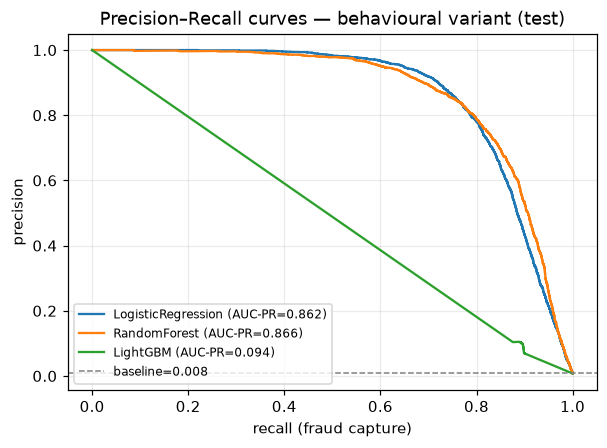

AUC-PR by model x variant:


variant,behavioural,full
model,,
LightGBM,0.0943,0.4467
LogisticRegression,0.8616,0.9051
RandomForest,0.8660,0.9956


table  -> Module_08/auc_pr_by_variant.csv

(ROC-AUC is near 1.0 for most variants — omitted as the decision metric; AUC-PR is used because ROC-AUC misleads at 0.77% prevalence.)


In [4]:
from sklearn.metrics import (average_precision_score, roc_auc_score,
                             precision_recall_curve)

prevalence = y_test.mean()
ap_scores = {k: average_precision_score(y_test, p) for k, p in proba.items()}

# PR curves for behavioural variants (the meaningful comparison)
fig, ax = plt.subplots(figsize=(6.2, 4.2))
for (variant, name), p in proba.items():
    if variant != "behavioural":
        continue
    prec, rec, _ = precision_recall_curve(y_test, p)
    ax.plot(rec, prec, label=f"{name} (AUC-PR={ap_scores[(variant,name)]:.3f})")
ax.axhline(prevalence, ls="--", c="grey", lw=1, label=f"baseline={prevalence:.3f}")
ax.set_xlabel("recall (fraud capture)"); ax.set_ylabel("precision")
ax.set_title("Precision–Recall curves — behavioural variant (test)"); ax.legend(fontsize=8)
save_fig(fig, "m5_01_pr_curves"); plt.show()

ap_table = (pd.Series(ap_scores).rename("AUC_PR").reset_index()
            .rename(columns={"level_0": "variant", "level_1": "model"})
            .pivot(index="model", columns="variant", values="AUC_PR").round(4))
print("AUC-PR by model x variant:"); display(ap_table)
save_table(ap_table, "auc_pr_by_variant")
print(f"\n(ROC-AUC is near 1.0 for most variants — omitted as the decision metric; "
      f"AUC-PR is used because ROC-AUC misleads at {prevalence*100:.2f}% prevalence.)")

## 4. The cost model & threshold selection

**Reasoning.** This is the module's core. For any threshold `t`, define

```
net_cost(t) = missed_fraud_value            # Σ amount of frauds we let through (C_fn ≈ amount)
            + C_fp × (number of false positives)   # fixed review + friction cost per wrongly blocked order
```

We sweep `t` across [0, 1] for every model variant, pick the `t*` that **minimises**
`net_cost`, report precision/recall/F1 at `t*`, and compare against the naive
**approve-everything** baseline (cost = the entire fraud value) to quantify
**financial loss avoided**.

**What to look for.** A U-shaped cost curve with a clear minimum; `t*` away from 0.5;
large savings vs approve-all. The *behavioural* variants are the defensible operating
choices; *full* variants are reported for completeness with the PaySim caveat.

> **On a stratified sample this threshold can collapse toward 0** (block almost
> everything): with fraud oversampled, each missed fraud's dollar value dwarfs the
> fixed `C_fp`, so there is no false-positive pressure. At the **full data's true
> prevalence** there are far more legit transactions per fraud, that pressure returns,
> and `t*` settles at a sensible interior value. Read the full-run numbers as
> authoritative; the sample validates the *mechanism*, not the operating point.

**Business tie-in.** The output is an operating policy — "block above score `t*`" — with
an explicit dollar rationale a risk committee can sign off on.

In [5]:
from sklearn.metrics import precision_score, recall_score, f1_score

C_FP = 10.0          # $ cost of a false alarm (review + friction); swept below
CHARGEBACK_FEE = 0.0 # optional fixed fee per missed fraud (C_fn = amount + fee)

def sweep_costs(y_true, p, amount, c_fp, fee=0.0, grid=None):
    y_true = np.asarray(y_true)
    if grid is None: grid = np.linspace(0.0, 1.0, 501)
    rows = []
    for t in grid:
        pred = p >= t
        fn = (y_true == 1) & (~pred); fp = (y_true == 0) & pred; tp = (y_true == 1) & pred
        net = amount[fn].sum() + fee * fn.sum() + c_fp * fp.sum()
        rows.append((t, net, amount[fn].sum(), amount[tp].sum(), int(fp.sum()),
                     int(tp.sum()), int(fn.sum())))
    return pd.DataFrame(rows, columns=["t","net_cost","missed_value","loss_avoided",
                                       "n_fp","n_tp","n_fn"])

approve_all_cost = amount_test[y_test.values == 1].sum()
summary, cost_curves = [], {}
for (variant, name), p in proba.items():
    sweep = sweep_costs(y_test.values, p, amount_test, C_FP, CHARGEBACK_FEE)
    cost_curves[(variant, name)] = sweep
    best = sweep.loc[sweep.net_cost.idxmin()]; t = best.t; pred = p >= t
    summary.append({
        "variant": variant, "model": name,
        "AUC_PR": round(ap_scores[(variant, name)], 4),
        "threshold*": round(t, 3),
        "precision": round(precision_score(y_test, pred, zero_division=0), 4),
        "recall": round(recall_score(y_test, pred, zero_division=0), 4),
        "F1": round(f1_score(y_test, pred, zero_division=0), 4),
        "net_cost": round(best.net_cost, 0),
        "n_fp": int(best.n_fp),
        "savings_vs_approve_all": round(approve_all_cost - best.net_cost, 0),
    })
comp = pd.DataFrame(summary).set_index(["variant", "model"]).sort_values("net_cost")
display(comp); save_table(comp, "model_comparison")
print(f"\napprove-all baseline cost (all fraud $ lost): {approve_all_cost:,.0f}")

AUC_PR  threshold*  precision  recall      F1  \
variant     model                                                               
full        RandomForest        0.9956       0.032     0.1184  0.9998  0.2117   
behavioural RandomForest        0.8660       0.004     0.0128  0.9988  0.0252   
full        LogisticRegression  0.9051       0.000     0.0077  1.0000  0.0153   
            LightGBM            0.4467       0.000     0.0077  1.0000  0.0153   
behavioural LogisticRegression  0.8616       0.000     0.0077  1.0000  0.0153   
            LightGBM            0.0943       0.000     0.0077  1.0000  0.0153   

                                 net_cost    n_fp  savings_vs_approve_all  
variant     model                                                          
full        RandomForest         353972.0   31703            6.702241e+09  
behavioural RandomForest        4534131.0  328519            6.698061e+09  
full        LogisticRegression  5482460.0  548246            6.697112e+09  
            LightGBM            5482460.0  548246            6.697112e+09  
behavioural LogisticRegression  5482460.0  548246            6.697112e+09  
            LightGBM            5482460.0  548246            6.697112e+09

table  -> Module_08/model_comparison.csv

approve-all baseline cost (all fraud $ lost): 6,702,594,765


## 5. Select the model & visualise the cost trade-off

**Reasoning.** We deploy the best **behavioural** variant — the one whose performance
comes from robust contextual signal, not PaySim's balance identity — chosen by lowest
net cost (ties broken by AUC-PR). We still report the full-variant winner alongside, so
the trade-off is transparent. We then plot the chosen model's cost curve with `t*`
marked.

**What to look for.** A defensible behavioural model with a clear cost optimum; the
full-variant number shown as the (inflated) PaySim ceiling for context.

**Business tie-in.** Deploying the behavioural model is the honest, evasion-resistant
choice; the cost curve is the artefact the risk team reviews to set policy.

DEPLOY (behavioural): RandomForest  |  threshold* = 0.004
(full-variant winner for reference: RandomForest — inflated by PaySim balance identity)
figure -> Module_08/figures/m5_02_cost_curve.png


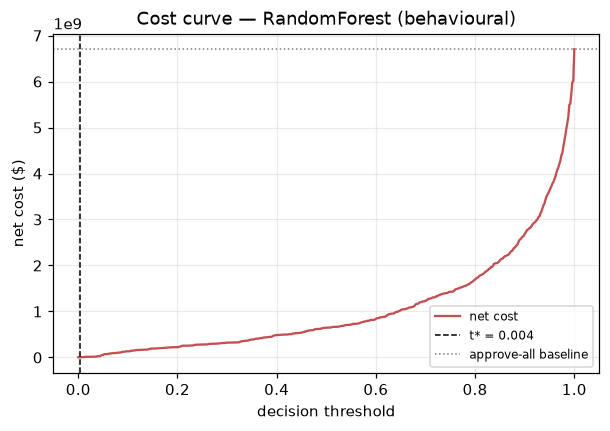

In [6]:
behav = comp.xs("behavioural", level="variant").sort_values("net_cost")
best_name = behav.index[0]
best_model = models[("behavioural", best_name)]
best_cols = FEATURE_SETS["behavioural"]
sweep = cost_curves[("behavioural", best_name)]
t_star = float(sweep.loc[sweep.net_cost.idxmin(), "t"])

full_best = comp.xs("full", level="variant").sort_values("net_cost").index[0]
print(f"DEPLOY (behavioural): {best_name}  |  threshold* = {t_star:.3f}")
print(f"(full-variant winner for reference: {full_best} — inflated by PaySim balance identity)")

fig, ax = plt.subplots(figsize=(6.4, 4))
ax.plot(sweep.t, sweep.net_cost, label="net cost", color="#C44E52")
ax.axvline(t_star, ls="--", c="k", lw=1, label=f"t* = {t_star:.3f}")
ax.axhline(approve_all_cost, ls=":", c="grey", lw=1, label="approve-all baseline")
ax.set_xlabel("decision threshold"); ax.set_ylabel("net cost ($)")
ax.set_title(f"Cost curve — {best_name} (behavioural)"); ax.legend(fontsize=8)
save_fig(fig, "m5_02_cost_curve"); plt.show()

## 6. Sensitivity analysis on `C_fp`

**Reasoning.** `C_fp` (the cost of a false alarm) is a business assumption, so we show
how the recommended operating point moves as it changes, for the deployed behavioural
model, across `C_fp ∈ {5, 10, 15, 20, 25}`.

**What to look for.** As false alarms get more expensive, `t*` rises (block less,
protect friction) and recall falls; as they get cheaper, `t*` drops (block more, catch
more fraud). A monotone, interpretable shift.

**Business tie-in.** A dial for the risk team: "if manual review costs $X, here is the
threshold and the fraud-capture/friction it implies."

In [7]:
best_p = proba[("behavioural", best_name)]
rows = []
for c_fp in [5, 10, 15, 20, 25]:
    sw = sweep_costs(y_test.values, best_p, amount_test, c_fp, CHARGEBACK_FEE)
    b = sw.loc[sw.net_cost.idxmin()]; pred = best_p >= b.t
    rows.append({"C_fp": c_fp, "threshold*": round(b.t, 3),
                 "recall": round(recall_score(y_test, pred, zero_division=0), 4),
                 "precision": round(precision_score(y_test, pred, zero_division=0), 4),
                 "n_fp": int(b.n_fp), "net_cost": round(b.net_cost, 0)})
sens = pd.DataFrame(rows).set_index("C_fp")
display(sens); save_table(sens, "cost_sensitivity")

,threshold*,recall,precision,n_fp,net_cost
C_fp,,,,,
5,0.002,0.9995,0.0108,389008,2608656.0
10,0.004,0.9988,0.0128,328519,4534131.0
15,0.004,0.9988,0.0128,328519,6176726.0
20,0.004,0.9988,0.0128,328519,7819321.0
25,0.004,0.9988,0.0128,328519,9461916.0


table  -> Module_08/cost_sensitivity.csv


## 7. Persist the model & decision policy for deployment

**Reasoning.** We save the chosen behavioural model and a **decision policy** JSON — the
threshold, cost assumptions, and the **exact feature subset** it uses — so the Module 6
API scores a live transaction with the same features and operating point, and Module 7
monitors against these settings.

**What to look for.** `best_model.joblib` and `decision_threshold.json` written with the
model name, `t*`, `C_fp`, and the behavioural feature list (not the full one).

**Business tie-in.** Deployment must reproduce the policy exactly; persisting it (not
re-deriving it live) makes the production decision auditable and stable.

In [8]:
joblib.dump(best_model, MODELS / "best_model.joblib")
metrics_row = comp.xs("behavioural", level="variant").loc[best_name].to_dict()
policy = {
    "model": best_name,
    "variant": "behavioural",
    "threshold": round(t_star, 4),
    "cost_model": {"C_fn": "transaction amount", "C_fp": C_FP,
                   "chargeback_fee": CHARGEBACK_FEE},
    "metrics_at_threshold": metrics_row,
    "features": best_cols,           # behavioural subset the model was trained on
    "label": LABEL,
    "note": "Deployed model excludes PaySim mechanical balance features to avoid "
            "simulator leakage. Threshold minimises net_cost on the temporal test "
            "fold; re-tune C_fp per current review economics (see cost_sensitivity)."
}
(MODELS / "decision_threshold.json").write_text(json.dumps(policy, indent=2, default=float))
print(f"saved -> {(MODELS/'best_model.joblib').relative_to(ROOT)}")
print(f"saved -> {(MODELS/'decision_threshold.json').relative_to(ROOT)}")
print(json.dumps({k: policy[k] for k in ['model','variant','threshold','cost_model']}, indent=2, default=float))

saved -> models/best_model.joblib
saved -> models/decision_threshold.json
{
  "model": "RandomForest",
  "variant": "behavioural",
  "threshold": 0.004,
  "cost_model": {
    "C_fn": "transaction amount",
    "C_fp": 10.0,
    "chargeback_fee": 0.0
  }
}


## 8. Notes & limitations (into Modules 6–8)

- **PaySim balance leakage is the headline finding.** Balance/amount features encode
  the fraud mechanism almost deterministically (AUC-PR ≈ 1.0 alone), so we deploy the
  **behavioural** variant that excludes them. This is the honest, evasion-resistant
  choice and the number to report; the full variant is context only.
- **Sample vs full data.** On the stratified sample the behavioural AUC-PR is inflated
  by oversampling; the full run at real prevalence (~0.13% overall) gives the true,
  lower number — read the full-run report as authoritative.
- **Threshold is data- and cost-dependent.** `t*` was chosen on the temporal test fold
  under an assumed `C_fp`; the sensitivity table re-tunes it as review economics change.
  Deployment loads it from `decision_threshold.json`.
- **Test prevalence differs from train** (temporal split; fraud clusters in time) —
  metrics are read against the *test* base rate.
- **No probability calibration / no hyperparameter tuning** — both are natural Module
  6/7 refinements (`CalibratedClassifierCV`, temporal-CV search); the comparison +
  cost-thresholding framework is the deliverable.